URL index: [Home](https://zzz.bwh.harvard.edu/luna-walkthrough/) | [Data](https://zzz.bwh.harvard.edu/luna-walkthrough/data/) | [S1. File QC](https://zzz.bwh.harvard.edu/luna-walkthrough/p1/) | [S2. Signal QC](https://zzz.bwh.harvard.edu/luna-walkthrough/p2) | [S3. Staging](https://zzz.bwh.harvard.edu/luna-walkthrough/p3) | [S4. Artifacts](https://zzz.bwh.harvard.edu/luna-walkthrough/p4) | [S5. Analysis](https://zzz.bwh.harvard.edu/luna-walkthrough/p5)

Notebook index: [Index](../00_index.ipynb) | [S1. File QC](../p1/00_index.ipynb) | [S2. Signal QC](../p2/00_index.ipynb) | [S3. Staging](../p3/00_index.ipynb) | [S4. Artifacts](../p4/00_index.ipynb) | [S5. Analysis](../p5/00_index.ipynb)

---

# 3.2. Hypnogram-based analysis

Walkthrough URL = [https://zzz.bwh.harvard.edu/luna-walkthrough/p3/hypno/](https://zzz.bwh.harvard.edu/luna-walkthrough/p3/hypno/)


In [1]:
import lunapi as lp
proj = lp.proj()
proj.sample_list( '../harm1.lst' )

initiated lunapi v1.2.3 <lunapi.lunapi0.luna object at 0x130887d30> 

read 20 individuals from ../harm1.lst


---
__Important__: please read all background materials [here](https://zzz.bwh.harvard.edu/luna-walkthrough/p3/hypno/).

## Checking the inputs

In [3]:
# luna harm1.lst -o out.db -s HYPNO
res = proj.silent_proc( 'HYPNO' )

In [5]:
# destrat out.db +HYPNO -v CONF
proj.table( 'HYPNO' )[ [ 'ID', 'CONF' ] ]

,ID,CONF
0,F01,0
1,F02,0
2,F03,0
3,F04,0
4,F05,0
5,F06,0
6,F07,0
7,F08,0
8,F09,0
9,F10,0


Good, above we see no _conflicts_ meaning that stages and epochs now align in the harmonized recording set.

## Core hypnogram statistics

We can now look at some standard statistics: e.g. stage durations.

In [12]:
# destrat out.db +HYPNO -c SS/N1,N2,N3,R,W -v MINS
tbl = proj.table( 'HYPNO' , 'SS' )[[ 'ID', 'SS', 'MINS' ]]  
tbl = tbl[ tbl.SS.isin( ['N1','N2','N3','R','W'] ) ] 
tbl.pivot( index='ID', columns='SS', values='MINS').reset_index()

SS,ID,N1,N2,N3,R,W
0,F01,27.5,180.5,74.0,59.0,80.5
1,F02,18.0,208.0,72.5,90.0,31.0
2,F03,36.5,111.0,86.0,51.0,150.5
3,F04,25.5,189.0,84.5,69.0,67.0
4,F05,39.0,190.0,70.5,57.0,91.5
5,F06,22.5,223.0,67.5,76.0,19.5
6,F07,12.5,213.0,21.0,70.5,155.0
7,F08,54.0,183.0,51.5,65.5,67.0
8,F09,22.0,238.5,31.5,73.5,24.0
9,F10,40.5,213.0,42.0,73.5,91.5


Doing the same for the other stage labels (e.g. unknown, lights on, all sleep or all NREM):

In [14]:
tbl = proj.table( 'HYPNO' , 'SS' )[[ 'ID', 'SS', 'MINS' ]]  
tbl = tbl[ tbl.SS.isin( ['S','NR','WASO','L','?'] ) ] 
tbl.pivot( index='ID', columns='SS', values='MINS').reset_index()

SS,ID,?,L,NR,S,WASO
0,F01,0.0,0.0,282.0,341.0,39.5
1,F02,0.0,11.0,298.5,388.5,12.0
2,F03,0.0,0.0,233.5,284.5,125.0
3,F04,0.0,3.5,299.0,368.0,49.5
4,F05,0.0,0.0,299.5,356.5,71.0
5,F06,0.0,0.0,313.0,389.0,13.0
6,F07,0.0,0.0,246.5,317.0,145.5
7,F08,0.0,0.0,288.5,354.0,33.5
8,F09,0.0,0.0,292.0,365.5,23.5
9,F10,0.0,0.0,295.5,369.0,36.5


Looking at all base hypnogram metrics for one individual:

In [16]:
# destrat out.db +HYPNO -i M07 | behead
tbl = proj.table( 'HYPNO' ) 
tbl = tbl[ tbl.ID == 'M07' ] 
tbl.T

,16
ID,M07
CONF,0
E0_START,0
E1_LIGHTS_OFF,0.0
E2_SLEEP_ONSET,79.000
E3_SLEEP_MIDPOINT,289.000
E4_FINAL_WAKE,499.000
E5_LIGHTS_ON,499.000
E6_STOP,499.000
EINS,1


Stage-specific example outputs (N2 only here):

In [21]:
# destrat out.db +HYPNO -r SS/N2 -i M07 | behead
tbl = proj.table( 'HYPNO', 'SS' ) 
tbl = tbl[ ( tbl.ID == 'M07' ) & ( tbl.SS == 'N2' ) ] 
tbl.T

,76
ID,M07
SS,N2
BOUT_05,177.0
BOUT_10,140.0
BOUT_MD,2.5
BOUT_MN,5.564103
BOUT_MX,32.0
BOUT_N,39
DENS,0.516667
MINS,217.0


## Hypnogram-based annotations

To stratify analyses of N2 sleep by the first four NREM cycles, here running for one individual (`F02`) and one channel (Cz) for illustration:

In [24]:
#luna harm1.lst -o out.db id=F02 \
# -s ' HYPNO annot
#      MASK ifnot=N2 & RE
#      TAG CYC/1 & MASK ifnot=h_cycle_n1
#      PSD sig=CZ dB
#      TAG CYC/2 & MASK ifnot=h_cycle_n2
#      PSD sig=CZ dB 
#      TAG CYC/3 & MASK ifnot=h_cycle_n3 
#      PSD sig=CZ dB 
#      TAG CYC/4 & MASK ifnot=h_cycle_n4
#      PSD sig=CZ dB '

proj.var( 'id' , 'F02' )

res = proj.silent_proc( ''' 
      HYPNO annot
      MASK ifnot=N2 & RE
      TAG CYC/1 & MASK ifnot=h_cycle_n1
      PSD sig=CZ dB
      TAG CYC/2 & MASK ifnot=h_cycle_n2
      PSD sig=CZ dB 
      TAG CYC/3 & MASK ifnot=h_cycle_n3 
      PSD sig=CZ dB 
      TAG CYC/4 & MASK ifnot=h_cycle_n4
      PSD sig=CZ dB ''' )


A few minor syntactical points:

 - the `TAG` adds a factor `CYC` to the output, with levels 1, 2, 3 and 4, which disambiguate what would otherwise be "overlapping" output from repeated runs of `PSD`

 - the `PSD` command respects current masks (i.e. one does not need to restructure the data with `RE`)

Looking at the output, e.g. just for delta power, stratified by cycle:

In [26]:
# destrat out.db +PSD -r B/DELTA CH CYC -p 3 
tbl = proj.table( 'PSD' , 'B_CH_CYC' ) 
tbl[ tbl.B == 'DELTA' ]

,ID,B,CH,CYC,PSD,RELPSD
8,F02,DELTA,CZ,1,25.581865,0.454696
9,F02,DELTA,CZ,2,24.355649,0.37901
10,F02,DELTA,CZ,3,23.09331,0.266553
11,F02,DELTA,CZ,4,23.642682,0.378916


## Hypnogram visualization

Epoch-level outputs can be obtained by adding the `epoch` option (this runs just for `F02` because the above `id` option is still in effect):

In [28]:
# luna harm1.lst -o out.db -s ' HYPNO epoch '
res = proj.silent_proc( 'HYPNO epoch' ) 

In [29]:
# destrat out.db +HYPNO -r E > tmp/hypno.epochs
tbl = proj.table( 'HYPNO' , 'E' ) 

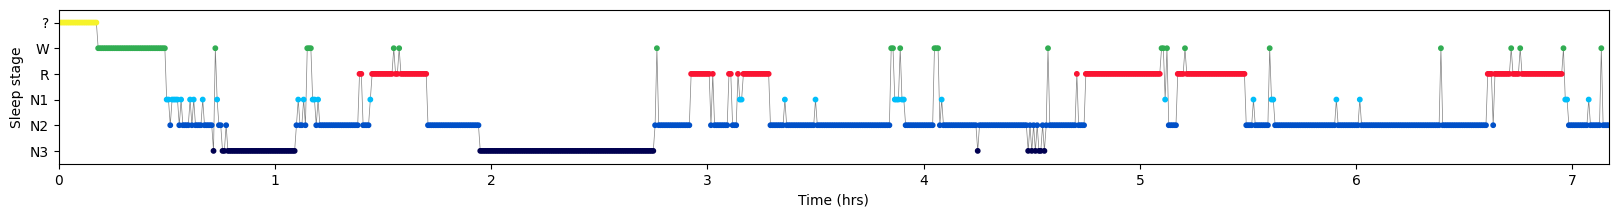

In [30]:
# library(luna)
# d <- read.table("tmp/hypno.epochs",header=T,stringsAsFactors=F)
# lhypno( d$STAGE[ d$ID == "F02" ] )
lp.hypno( tbl.STAGE )

For all 20 individuals: we first clear the `id` option and repeat:

In [39]:
proj.var( 'id' , '' )
res = proj.silent_proc( 'HYPNO epoch' ) 
tbl = proj.table( 'HYPNO' , 'E' ) 
tbl

,ID,E,AFTER_GAP,CLOCK_HOURS,CLOCK_TIME,CYCLE,CYCLE_POS_ABS,CYCLE_POS_REL,E_N1,E_N2,...,TOT_R2W,TOT_W2NR,TOT_W2R,TR_NR2R,TR_NR2W,TR_R2NR,TR_R2W,TR_W2NR,TR_W2R,WASO
0,F01,1,0,22,22:00:00,None,None,None,0.0,0.0,...,0,0,0,0,0,0,0,75,0,0.0
1,F02,1,0,22,22:00:00,None,None,None,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0.0
2,F03,1,0,22,22:00:00,None,None,None,0.0,0.0,...,0,0,0,0,0,0,0,51,0,0.0
3,F04,1,0,22,22:00:00,None,None,None,0.0,0.0,...,0,0,0,0,0,0,0,34,0,0.0
4,F05,1,0,22,22:00:00,None,None,None,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17989,M07,994,0,6.275,06:16:30,4,56.5,0.957627,20.0,214.5,...,0,0,0,0,0,0,0,0,0,0.0
17990,M07,995,0,6.28333,06:17:00,4,57.0,0.966102,20.0,215.0,...,0,0,0,0,0,0,0,0,0,0.0
17991,M07,996,0,6.29167,06:17:30,4,57.5,0.974576,20.0,215.5,...,0,0,0,0,0,0,0,0,0,0.0
17992,M07,997,0,6.3,06:18:00,4,58.0,0.983051,20.0,216.0,...,0,0,0,0,0,0,0,0,0,0.0


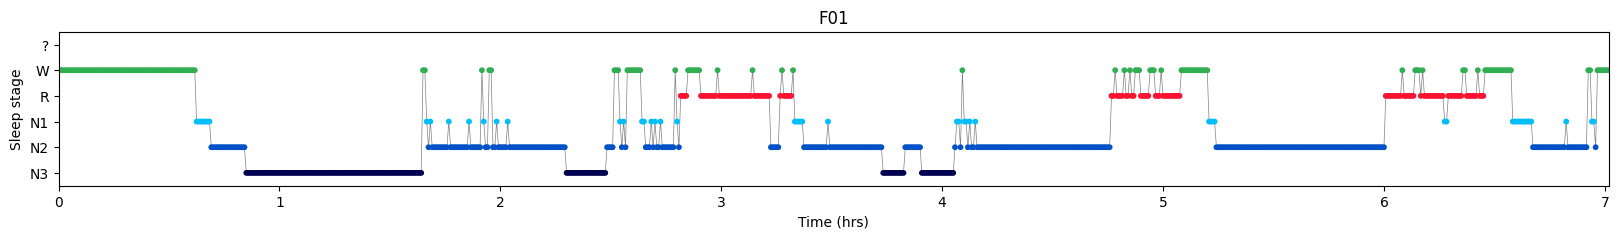

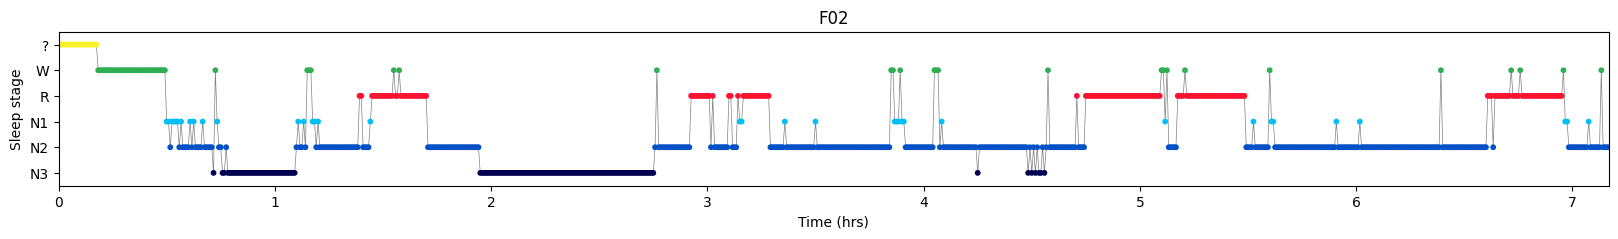

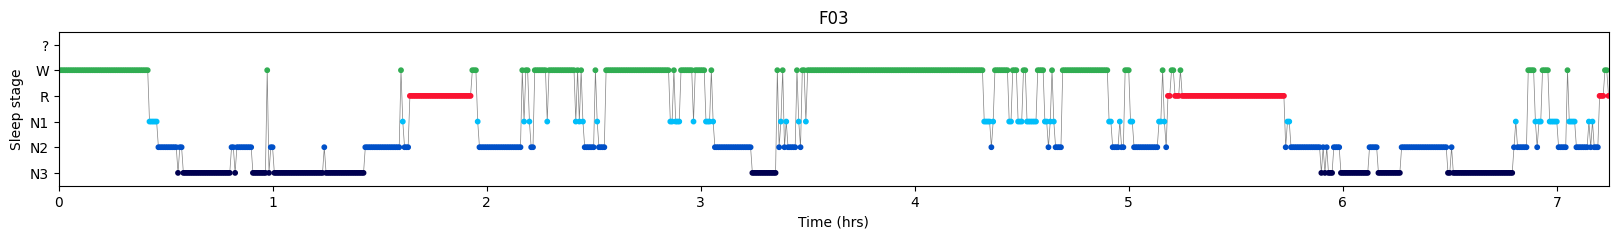

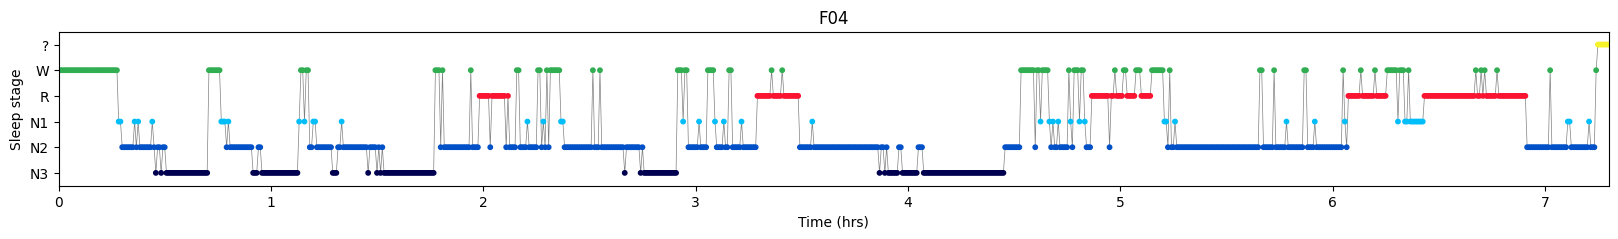

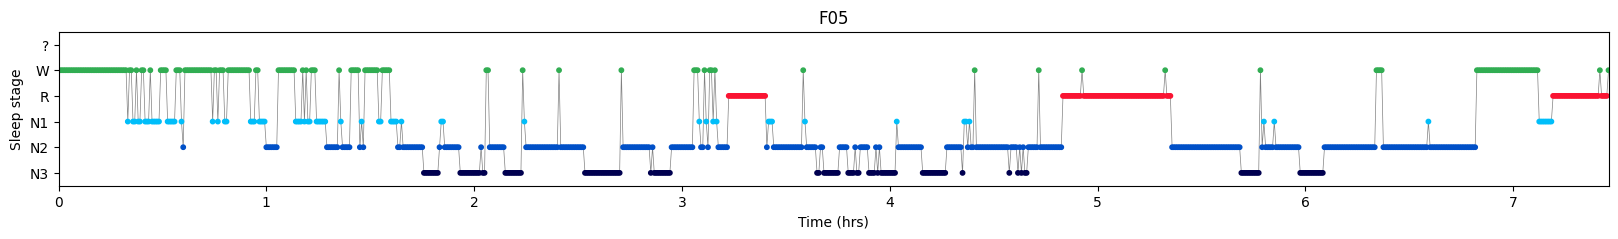

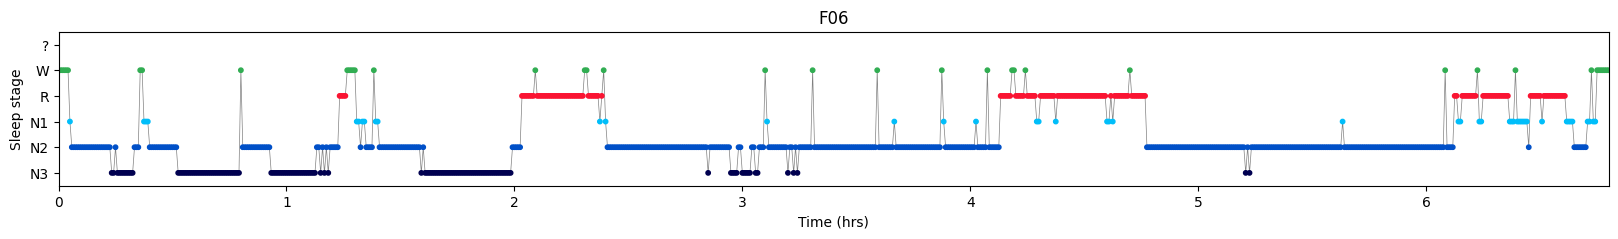

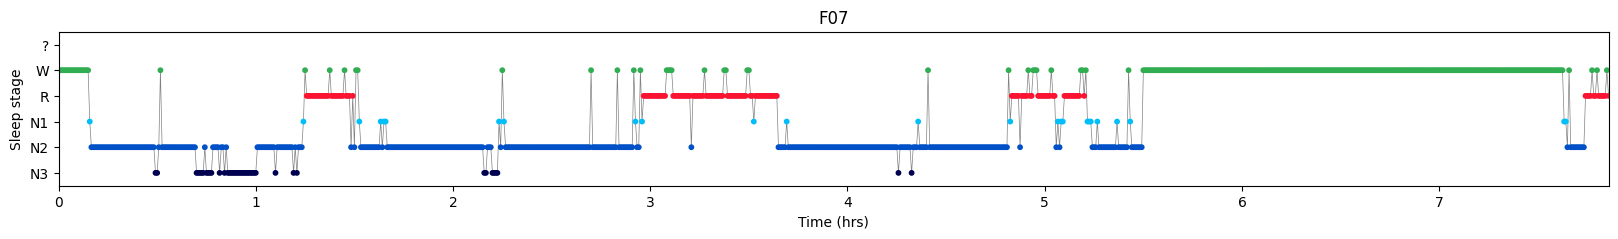

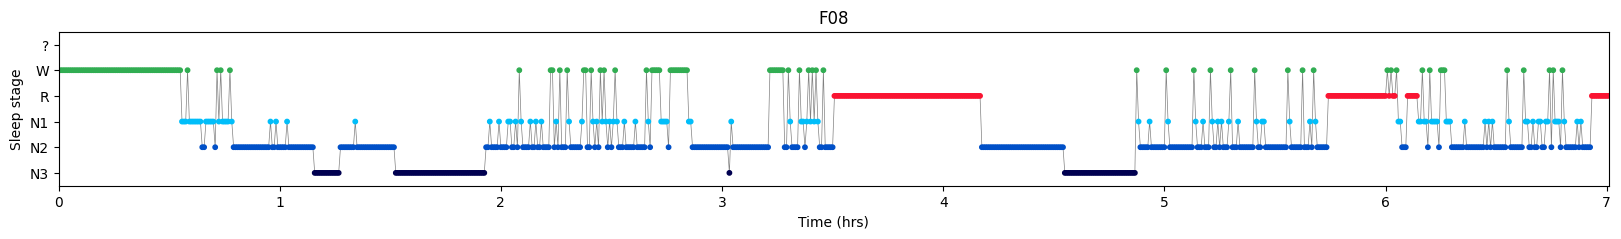

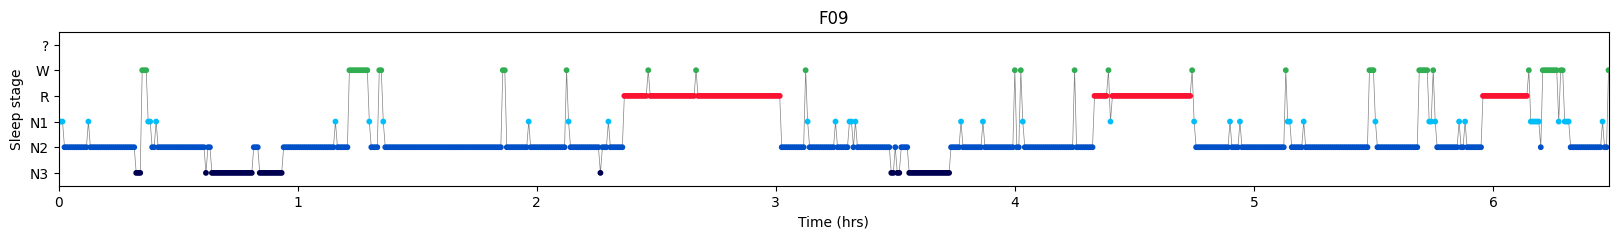

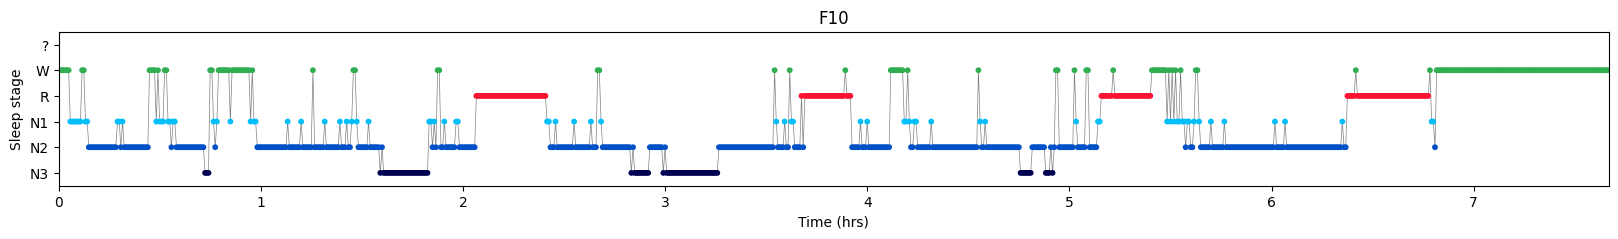

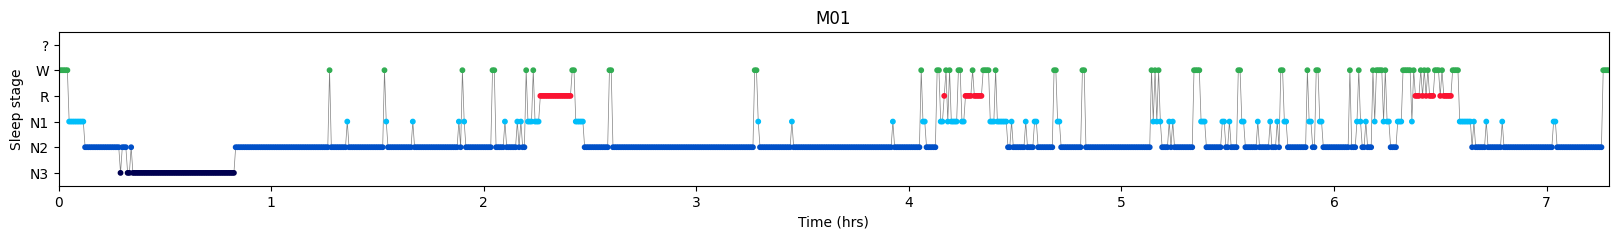

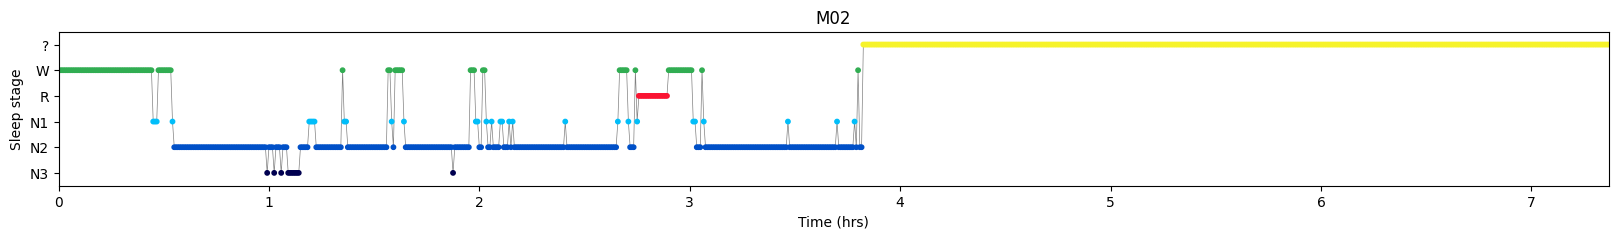

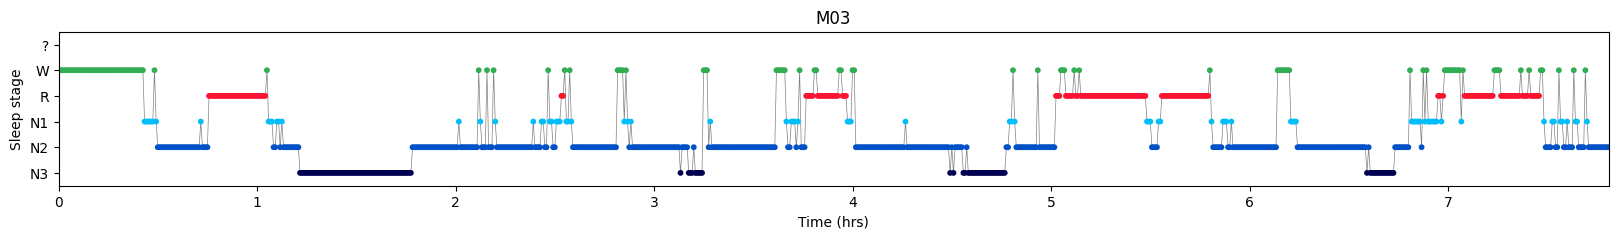

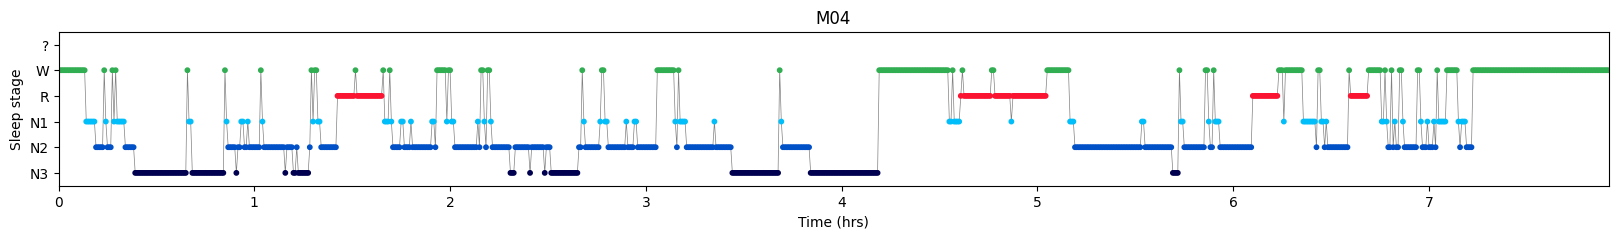

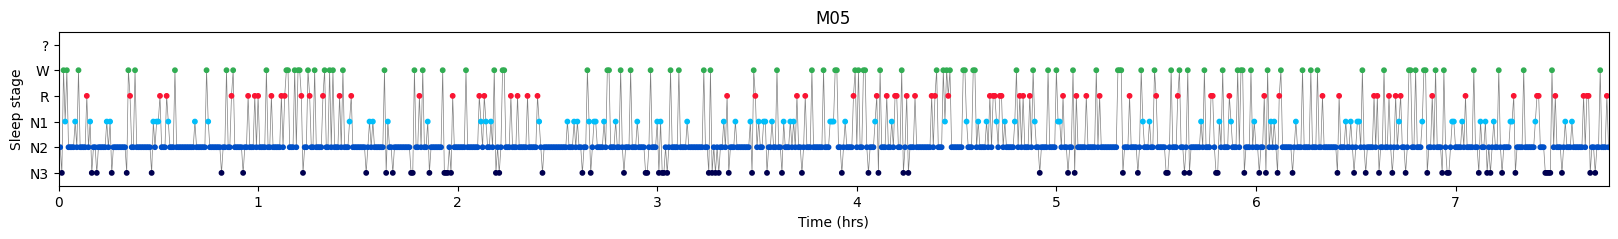

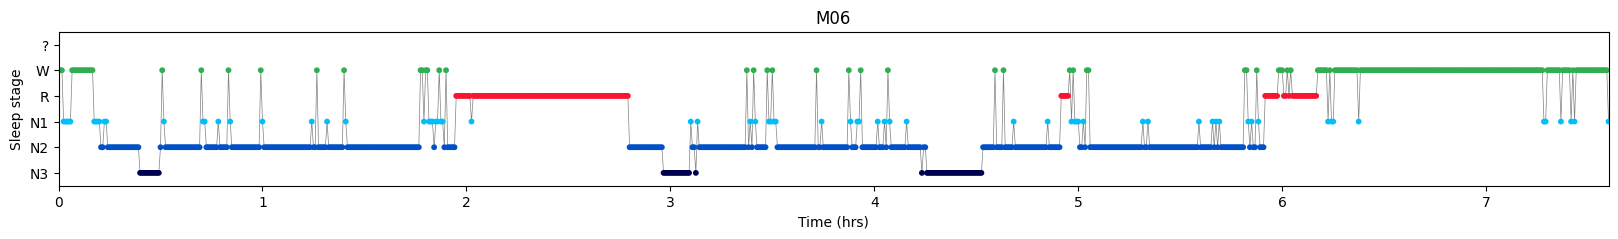

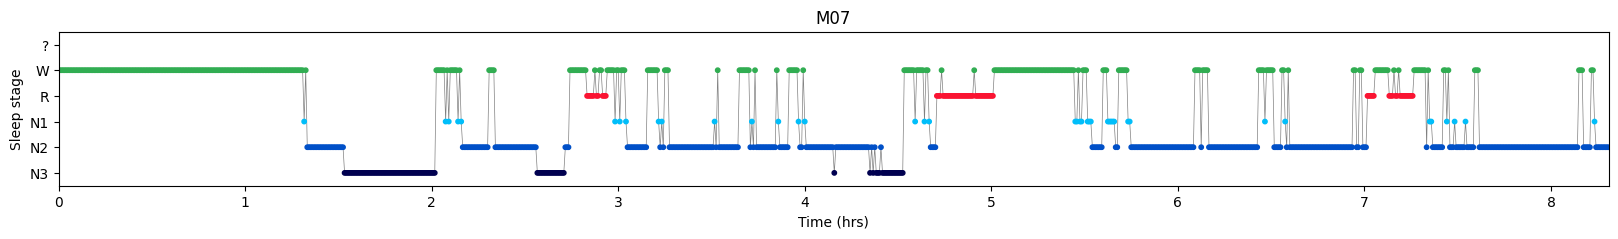

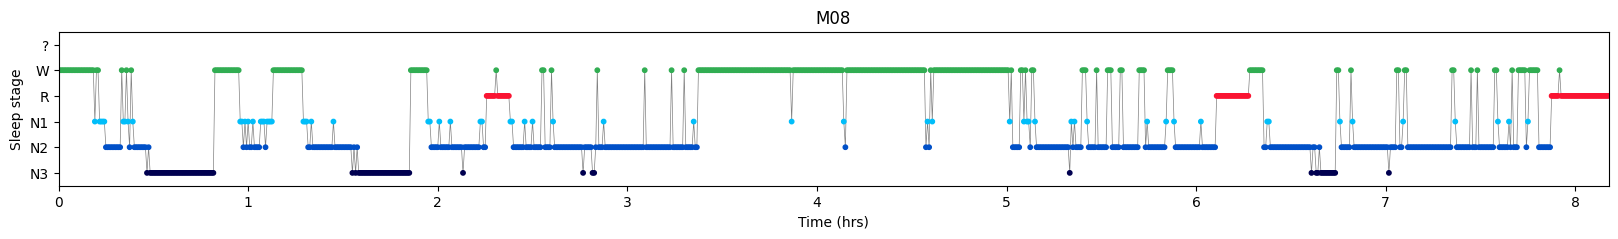

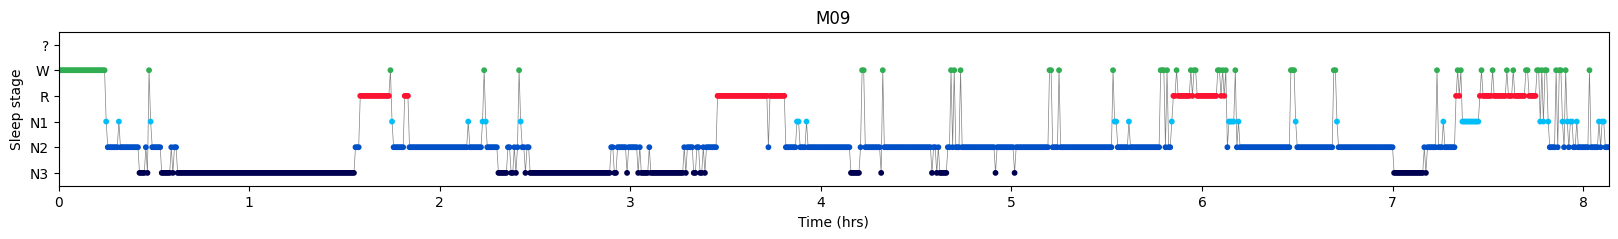

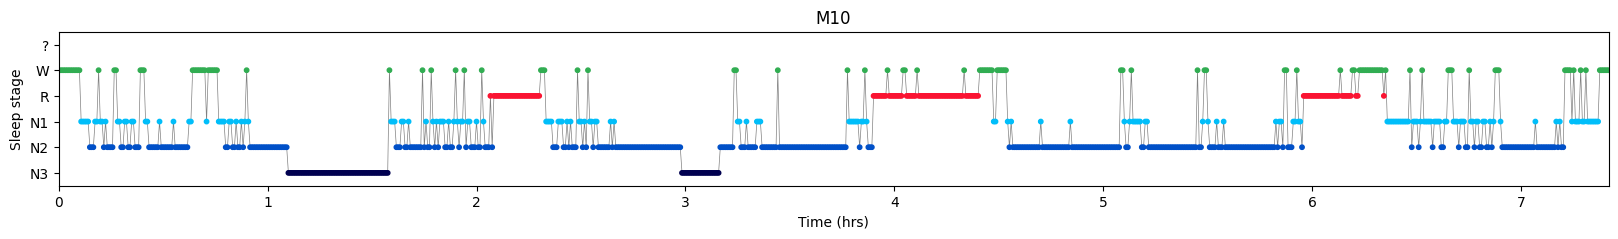

In [43]:
ids = tbl.ID.unique()
for id in ids: lp.hypno( tbl.STAGE[ tbl.ID == id ] , title = id ) 

## Epoch-level statistics

From the previous run of `HYPNO`, there are also a number of epoch-level statistics that can be used in analyses or for visualization.  See the original walkthrough for [an example](https://zzz.bwh.harvard.edu/luna-walkthrough/p3/hypno/#epoch-level-statistics) of an epoch-level per-subject visualization of these stats.

---

We can now move to the [next section](03_soap.ipynb) using `SOAP` to evaluate staging/signal consistency.